Heatmap of results 20 years post-contamination for all scenarios and simulations

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import itertools
import warnings
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups

warnings.simplefilter('ignore')

In [2]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/data_all_bb.csv")

In [3]:
custom_order = ['Macroalgae', 'Seagrass', 'Pelag_Bact', 'Diatom', 'PicoPhytopl', 'MicroZoo', 
    'Zoo', 'Gelat_Zoo', 'Squid',  #'Zooplankton', 'Phytoplankton', 'Carniv_Zoo',  
    
    'Small_pelagic_fish',  'Small_Demersal_fish', 'Small_Flatfish', 
    'Benthopelagic', 'Large_Demersal_fish', 'Large_Flatfish','Rockfish',
    'Hake','Lingcod', 'Pollock', 'Sandlance','Pacific_herring', 
    'Chinook_salmon', 'Chum_salmon', 'Coho_salmon','Pink_salmon','Sockeye_salmon', 
    'Hatchery_Chinook_salmon','Hatchery_Coho_salmon','Hatchery_Sockeye_salmon','Other_salmonids',
    
    'Benthic_grazer', 'Filter_feeder', 'Macrobenthos',  
    'Sponges', 'Bivalves', 'Crabs', 'Dungeness_crabs',
    
    'Dogfish','Ratfish','Sixgill','Skates',

    'Harbor_porpoise', 'Harbor_seals', 'Sealions',
    'Orcas_resident', 'Orcas_transient','Humpback_whales',
    
    'Seabird_gulls','Seabirds',]

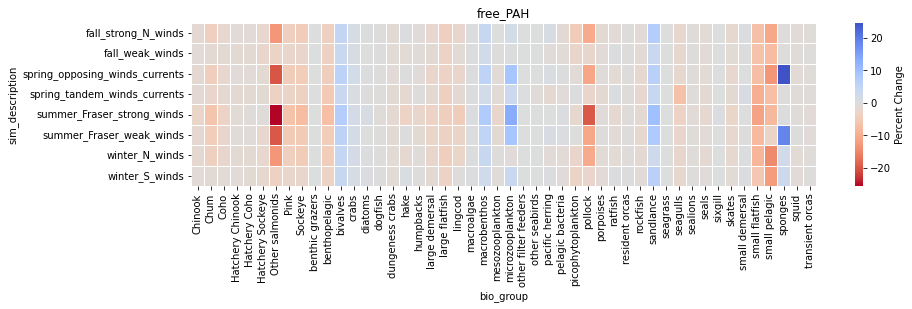

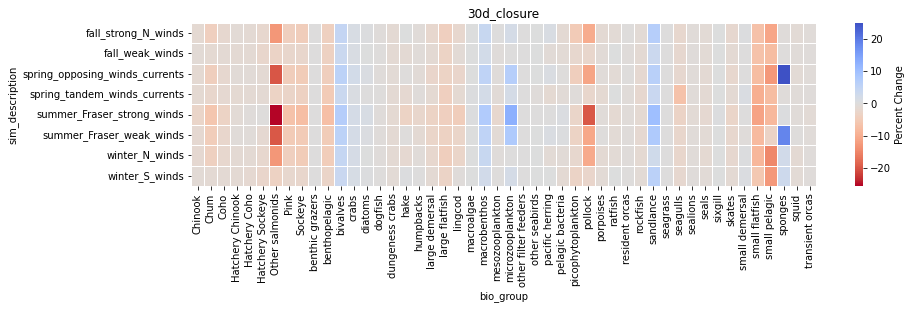

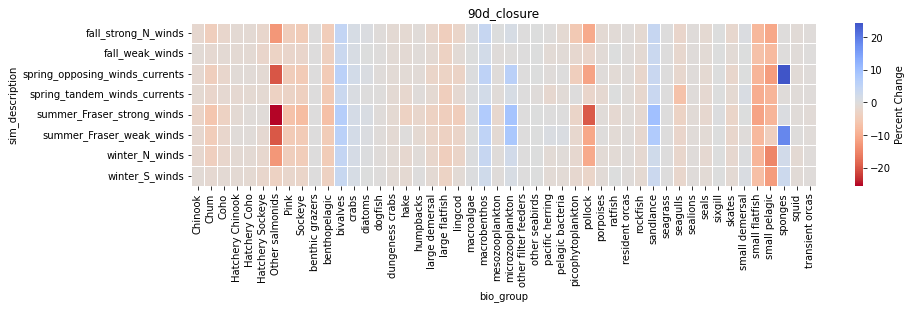

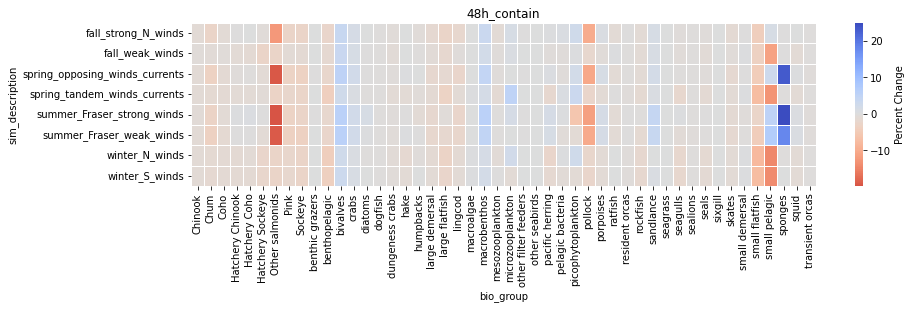

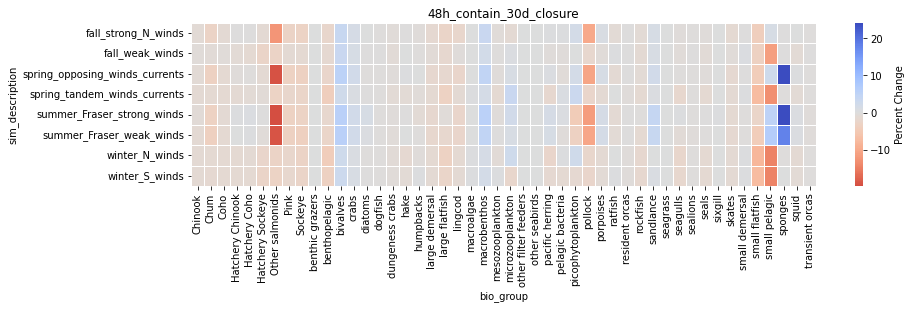

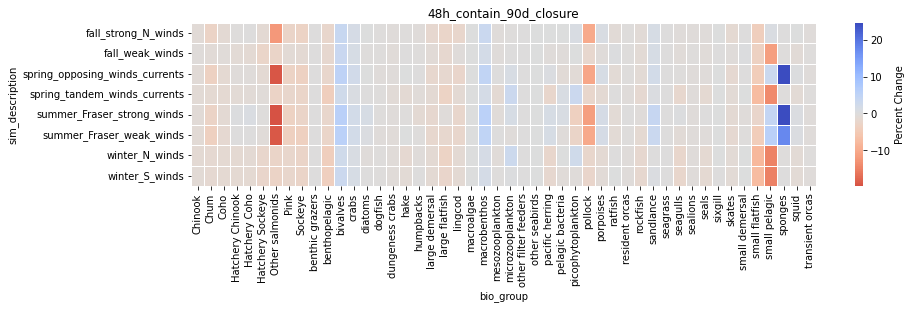

In [44]:
# Full data for Supplement
for scenario_label in [1,2,3,4,5,6]:
    df_plot = df[(df['scenario'] == scenario_label)]
    heatmap_data = df_plot.pivot(index='sim_description', columns='bio_group', values='percent_change')
    #heatmap_data = heatmap_data.columns.reindex(custom_order)
    plt.figure(figsize=(14, 3))
    ax = sns.heatmap(
    heatmap_data, 
    annot=False,
    fmt=".1f",
    cmap="coolwarm_r", 
    center=0, #vmin=-15, vmax=15,
    linewidths=0.5,
    #linecolor='gray',
    cbar_kws={'label': 'Percent Change'}
    )
    plt.title(groups.scenarios[str(scenario_label)])
    